In [12]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

df=fetch_california_housing()
df
dataset=pd.DataFrame(df.data)
dataset.columns=df.feature_names
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [17]:
# IndependentVariable features and dependent features
x=dataset
y=df.target
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.30, random_state=42)
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
7061,4.1312,35.0,5.882353,0.975490,1218.0,2.985294,33.93,-118.02
14689,2.8631,20.0,4.401210,1.076613,999.0,2.014113,32.79,-117.09
17323,4.2026,24.0,5.617544,0.989474,731.0,2.564912,34.59,-120.14
10056,3.1094,14.0,5.869565,1.094203,302.0,2.188406,39.26,-121.00
15750,3.3068,52.0,4.801205,1.066265,1526.0,2.298193,37.77,-122.45
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [33]:
from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler()
X_train= Scaler.fit_transform(X_train)
X_test=Scaler.transform(X_test)

In [40]:
from sklearn.linear_model import LinearRegression
# cross validition
from sklearn.model_selection import cross_val_score
reg=LinearRegression()
reg.fit(X_test,y_test)
mse=cross_val_score(reg, X_train,y_train, cv=10, scoring='neg_mean_squared_error')
mse

array([-0.56799593, -0.52918854, -0.48456478, -0.51627013, -0.54833859,
       -0.47884524, -0.47828648, -0.55465187, -0.55647389, -0.54248888])

In [36]:
np.mean(mse)

np.float64(-0.5257104326777)

In [43]:
reg_pre =reg.predict(X_test)
reg_pre

array([0.68478708, 1.78087175, 2.72212814, ..., 2.11982511, 1.56024922,
       1.85797296], shape=(6192,))

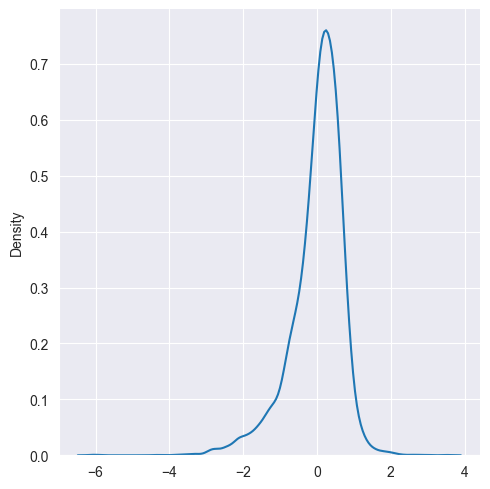

In [55]:
import seaborn as sns
sns.displot(reg_pre-y_test,kind='kde')

In [57]:
from sklearn.metrics import r2_score
sc=r2_score(reg_pre,y_test,multioutput='variance_weighted')
sc


0.3688523111566825